In [1]:
%cd ..
# !curl -L -o .\data\sprites.zip https://www.kaggle.com/api/v1/datasets/download/ebrahimelgazar/pixel-art
# !Expand-Archive -LiteralPath '.\data\sprites.zip'

/Users/daanwichmann/PycharmProjects/BSc Thesis


## Importing dependencies

In [2]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from project.models import EDMEvelynn, EDM2

In [3]:
device = "cpu"
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
print(f"Using: {device}")

Using: mps


## Setting hyperparameters

In [4]:
DATA = os.path.join("data", "sprites")
CHECKPOINT = os.path.join("parameters", "sprites-edm.pth")

In [5]:
MODEL = "EDMEvelynn"

In [6]:
BATCH_SIZE = 64
RESOLUTION = 32
IN_CHANNELS = 3
OUT_CHANNELS = 3
START_CHANNELS = 128
NUM_RES_BLOCKS = 2
CHANNEL_MULTIPLIERS = (1, 2, 2, 2)
ATTENTION_RESOLUTIONS = (16,)
LR = 2e-3
DROPOUT = 0.13

## Preparing dataset & dataloader

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=0.5,
        std=0.5
    )  # Normalize image between [-1, 1]
])

In [8]:
data = datasets.ImageFolder(
    root=DATA,
    transform=transform,
)
loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True)

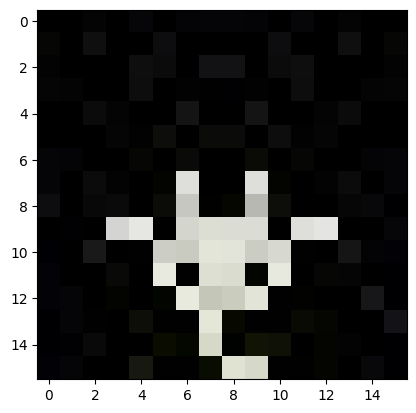

In [9]:
image, y = data[21]
image = (image + 1) / 2

plt.imshow(image.permute((1, 2, 0)))
plt.show()

## Setting up the model

In [10]:
edm_evelynn = EDMEvelynn(
    img_resolution=RESOLUTION,
    img_channels=IN_CHANNELS,
    start_channels=START_CHANNELS,
    channel_mult=CHANNEL_MULTIPLIERS,
    num_blocks=NUM_RES_BLOCKS,
    attention_resolutions=ATTENTION_RESOLUTIONS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    lr=LR
)
edm2 = EDM2(
    img_resolution=RESOLUTION,
    img_channels=IN_CHANNELS,
    start_channels=START_CHANNELS,
    channel_mult=CHANNEL_MULTIPLIERS,
    num_blocks=NUM_RES_BLOCKS,
    attention_resolutions=ATTENTION_RESOLUTIONS,
    batch_size=BATCH_SIZE,
    lr=LR
)

model = edm_evelynn if MODEL == "EDMEvelynn" else edm2

In [11]:
if os.path.exists(CHECKPOINT):
    model.load_checkpoint(CHECKPOINT)
    print("Loaded checkpoint!")

## Training the model

In [12]:
model.train(1, loader)

Epoch 1:   0%|          | 5/1397 [00:13<1:04:47,  2.79s/it]

KeyboardInterrupt: 

In [18]:
model.save_checkpoint(CHECKPOINT)

In [31]:
x = model.heun_sampler(1)
x = (x + 1) / 2

tensor(0.5583, device='cuda:0') tensor(80.5987, device='cuda:0')


100%|██████████| 35/35 [00:02<00:00, 14.20it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027670264..1.0721856].


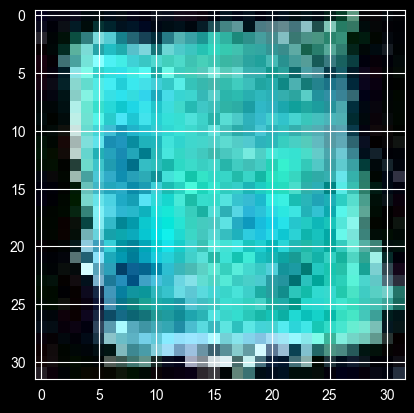

In [32]:
plt.imshow(x.to("cpu").squeeze().permute((1, 2, 0)))